# Longitude–Latitude Aerial View


This notebook examines the **horizontal spatial structure of ocean biogeochemical and physical anomalies** using longitude–latitude aerial maps across model simulations and observational products. It provides a configurable workflow for selecting variables, datasets, experiments, biomes, temporal periods, depth ranges, and derived physical quantities; loading and preparing the corresponding data; calculating climatological anomalies and ENSO composites; and visualizing their horizontal distribution.

The analysis is particularly useful for examining the **tropical and equatorial oceans**, where large-scale zonal and meridional gradients associated with circulation and ENSO strongly influence physical and biogeochemical variability. The workflow also supports vector-field visualization when paired variables such as winds or currents are available.

The notebook follows four main stages:

1. **Package and configuration setup** – Load the required analysis, plotting, and project configuration utilities.
2. **Data request configuration** – Select variables, datasets/experiments, observational sources, biomes, and optional derived physical quantities.
3. **Data loading and preparation** – Load and preprocess the requested datasets, calculate derived fields where requested, construct climatological anomalies, identify ENSO events, and apply the selected biome masks.
4. **Visualization** – Generate longitude–latitude aerial maps of anomalies and ENSO-related composites across the selected observations and model experiments.

## Biomes

The biomes defined here are Pacific Equatorial (PEQ), PEQ East and West (PEQ-E, PEQ-W), and Atlantic Equatorial (AEQ). The latitude range is configurable.

## Optional configurations

1. **`calculate_ekman`** – Optionally calculate **Ekman transport** when the required wind-stress variables are available. The derived field can then be included in the horizontal spatial analysis.

2. **`calculate_density`** – Optionally calculate **seawater density** when the required temperature and salinity variables are available. The resulting density field can then be visualized alongside the physical and biogeochemical variables.

3. **`mask_ENSO_events`** – Optionally restrict the analysis to selected **ENSO events**. The selected data can either be averaged by year and month or retain their time dimensions for subsequent temporal or seasonal averaging. The workflow can also calculate **La Niña minus El Niño composites**, representing climatological differences across the selected months and events.


### Package and configuration setup

In [4]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(1, '/home/rpg002/BGC_skill')

import numpy as np
import configs
from prepare import (prepare_data_for_analysis, 
                    load_ONI,
                    get_ekman,
                    get_density,
                     calculate_climatology, 
                     get_enso_events,
                     experiment_finder,
                     mask_EQ,
                     create_eq_biomes,
                     mask_NESO_events)

from modules.plotting.module_plot_2D import snapshot_aerial, snapshot_aerial_quiver
from modules.analysis.module_data_load import load_biomes
from modules.data_info.module_data_info import biomes_module


In [5]:
units = configs.units
boundaries_dict = configs.boundaries_dict
model_lev_bounds = configs.model_lev_bounds
model_levels = configs.model_levels
unit_change_dics = configs.unit_change_dics
varx = configs.varx
ENSO = configs.ENSO
contourf = configs.contourf
pcolor_ranges = configs.pcolor_ranges

### USer configs

In [ ]:
data_directory = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data'
biomes_directory =  "/space/hall7/sitestore/eccc/crd/cccma/users/rsa001/big_store/AI/FGCO2/data/biomes" 

assimilation_BGC_run_id = None
CanOE_assimilation_BGC_run_id = 1

var_list = ['uas', 'vas', 'uo']
experiment_list = ['observation','assimilation', 'historical']
model_list = ['CanESM5', 'CanESM5-CanOE']

 ## this could be a dictionary for each variable as they might have different sources or one source for all variables.
obs_source = { 'uas' : 'ERA5',
              'vas' : 'ERA5',
              'uo' : 'SODA'}
 
calculate_ekman: bool = True
calculate_density: bool = True

### Data Loading

In [7]:
dict_em_data, obs_mask, model_mask , mask_ocean_surface = prepare_data_for_analysis(var_list,
                            experiment_list,
                            model_list,
                            obs_source,
                            data_directory ,
                            unit_change_dics,
                            assimilation_BGC_run_id = None,
                            CanOE_assimilation_BGC_run_id = 1,
                            nldyr = 1, 
                            varx_dicts = varx,
                            target_levels=model_levels,
                            verbose = True)


observation directories: 

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/observation/ERA5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vas/observation/ERA5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uo/observation/SODA

model directories: 

uas assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/assimilation/CanESM5-CanOE_1
uas historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/historical/CanESM5-CanOE
vas assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vas/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vas/assimilation/CanESM5-CanOE_1
vas historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vas/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vas/histo

In [8]:
bms_info = biomes_module(biomes_directory)
bms_dict = bms_info.data_dict['biomes']
bms_dir  = bms_dict['dir']
bms_file = bms_dict['file']
bms_dict_plot = bms_info.dict_biomes_plot
nbms = 17
bms_labels = [bms_info.biomes_dict[ii]['label'] for ii in np.arange(nbms)+1]

biomes = load_biomes(f'{bms_dir}',
                     f'{bms_file}') * mask_ocean_surface

mask_biomes = create_eq_biomes(biomes, lat_max = 10, lat_min = -10)


loading global ocean biomes..
done


In [9]:
ONI_dict = load_ONI(experiment_list, 
                    model_list, 
                    assimilation_BGC_run_id,
                    CanOE_assimilation_BGC_run_id,
                    obs_source='SODA')

ElNino_dict, LaNina_dict = get_enso_events(ONI_dict)


In [10]:
idisplay=False

if idisplay:

    ax = plt.subplot(1,1,1)
    ax.pcolormesh(mask_ocean_surface.lon, mask_ocean_surface.lat, mask_ocean_surface.where(mask_ocean_surface ==0).values, vmin = 0, vmax =1)
    plt.scatter(-50.5, 43.5, color='red', s=10, label='My Point', zorder=10)

In [11]:
idisplay=False

if idisplay:
    print('checking loaded data')
    for var in dict_em_data:
        for exp in dict_em_data[var]:
            print(f'{var} {exp}')
            display(dict_em_data[var][exp].data)




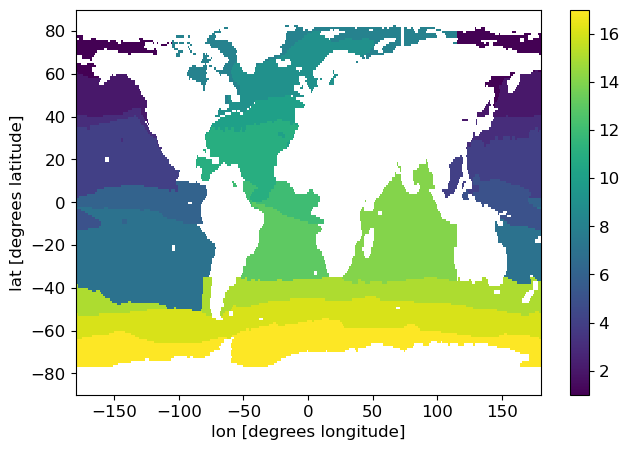

In [12]:
idisplay=True

if idisplay:
    (biomes.MeanBiomes * mask_ocean_surface ).where(biomes.MeanBiomes * mask_ocean_surface > 0).plot()


### Data Prep

In [13]:
if calculate_ekman:
    dict_em_data = get_ekman(dict_em_data)

if calculate_density: 
    dict_em_data = get_density(dict_em_data)

so or thetao does not exist. Density cannot be calculated.


In [14]:
dict_em_clim, dict_em_anom = calculate_climatology(dict_em_data,
                                                   y0_base=None,
                                                   y1_base=None,
                                                   return_anomaly=True,
                                                   center_on_zero=True)
                                           

calculating uas CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...
done.
calculating uas CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating uas CanESM5-CMOC_historical climatology over 1980 - 2023 ...
done.
calculating uas CanESM5-CanOE_historical climatology over 1980 - 2023 ...
done.
calculating uas obs climatology over 1980 - 2023 ...
done.
calculating vas CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...
done.
calculating vas CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating vas CanESM5-CMOC_historical climatology over 1980 - 2023 ...
done.
calculating vas CanESM5-CanOE_historical climatology over 1980 - 2023 ...
done.
calculating vas obs climatology over 1980 - 2023 ...
done.
calculating uo CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...
done.
calculating uo CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating uo CanESM5-CMOC_historical climatology over 1980 - 2023 ...

In [15]:
dict_em_LaNina, dict_em_ElNino, dict_em_diff = mask_NESO_events(dict_em_anom,
                                                  ONI_dict,
                                                  calculate_mean = False,
                                                  upper_percentile=75,
                                                  lower_percentile=25,
                                                  return_diff=True)



In [16]:
dict_em_anom =  mask_EQ(dict_em_anom, mask_biomes)    
dict_em_LaNina = mask_EQ(dict_em_LaNina, mask_biomes) 
dict_em_ElNino = mask_EQ(dict_em_ElNino, mask_biomes) 
dict_em_diff = mask_EQ(dict_em_diff, mask_biomes) 

### Plots

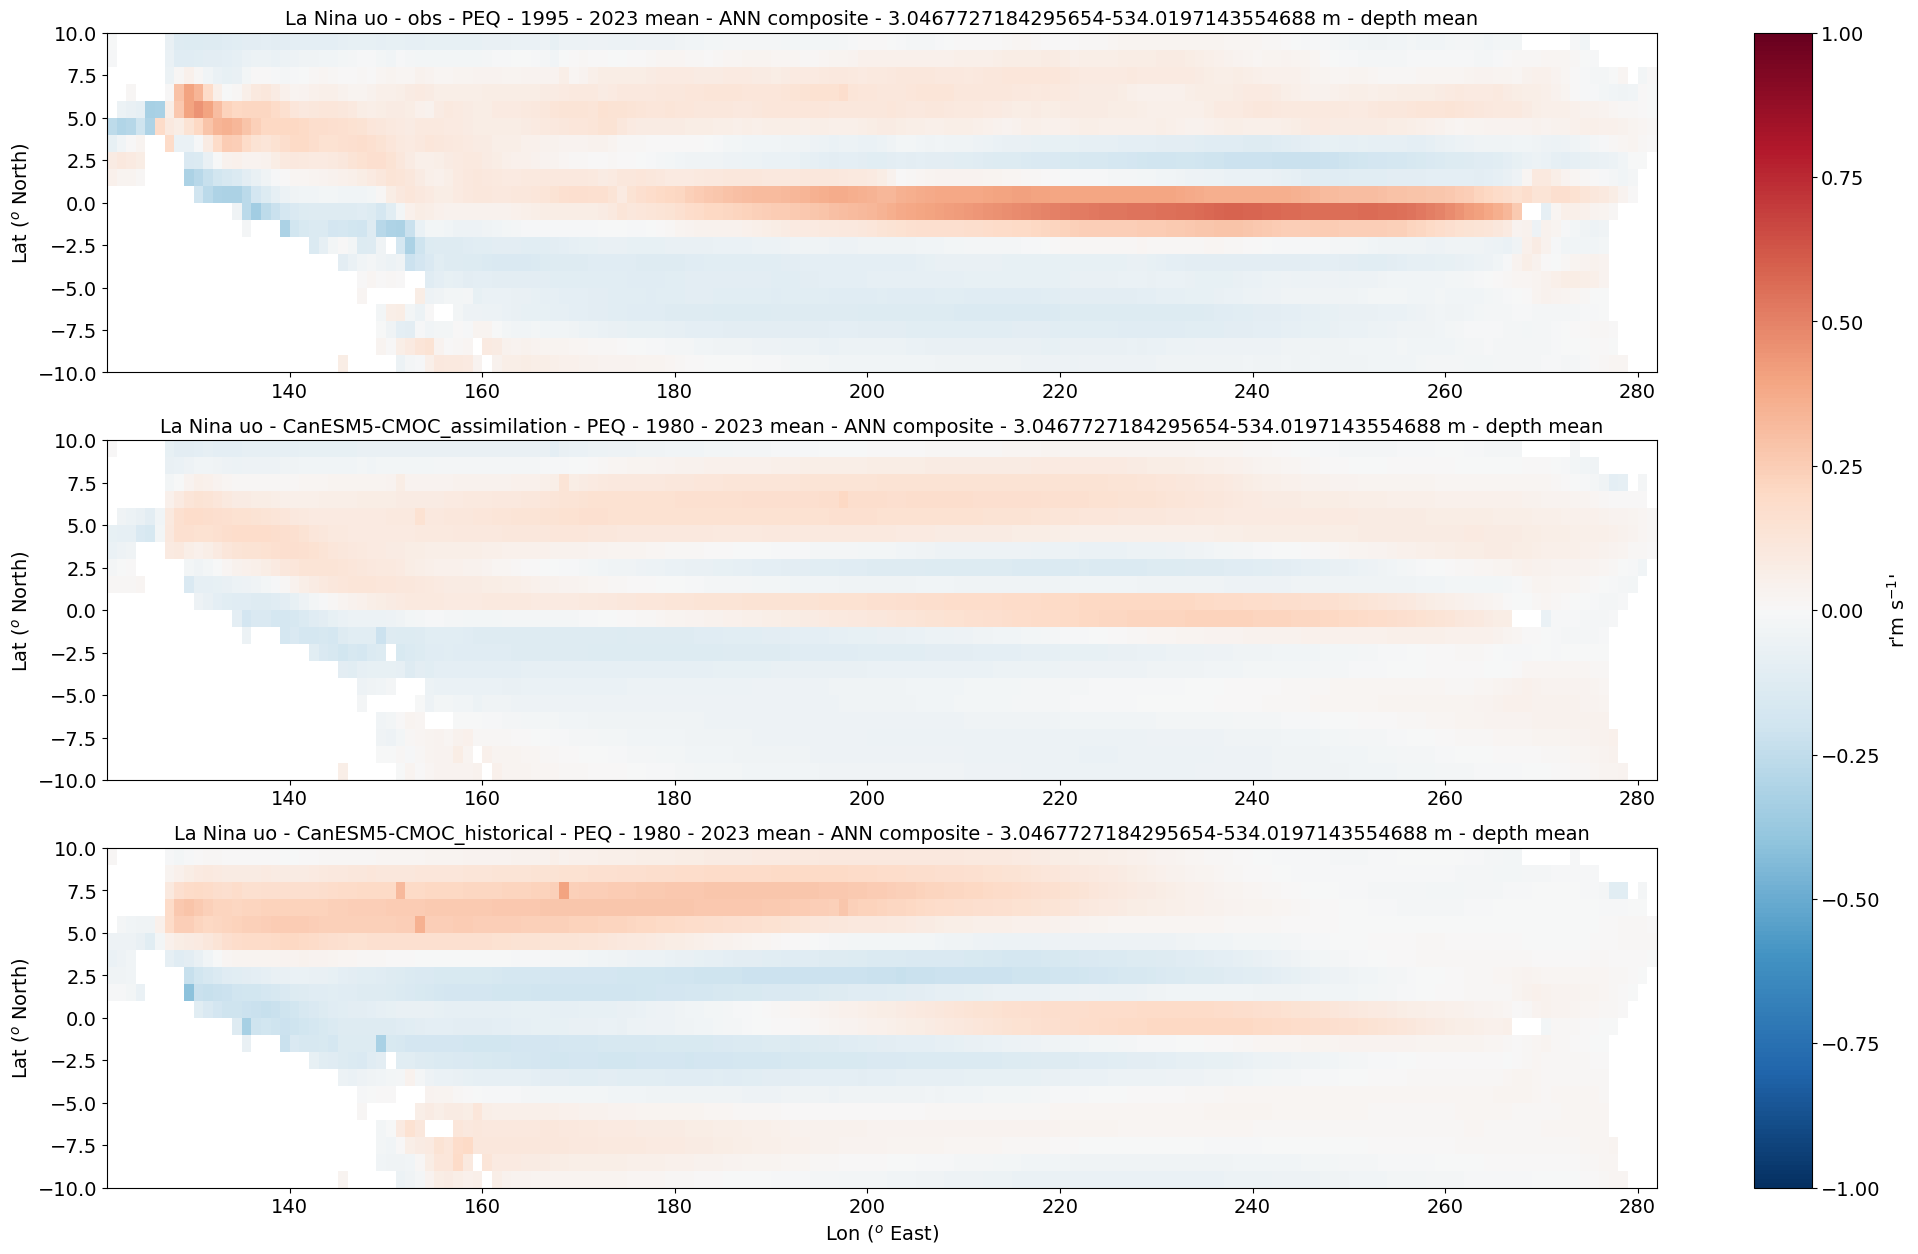

In [ ]:
var = 'uo'

model_experiment = ['observation', 'CanESM5 assimilation', 'CanESM5 historical']
season_to_plot = 'ANN'
figsize = (25,15)


title = f'La Nina {var}'
bms_label =  'PEQ'
colorbar_label = units[var]
lev_range = 600
longitude = 260

ds_dicts = dict_em_LaNina[var]
ds_list = experiment_finder(dict_em_data[var], model_experiment)


snapshot_aerial(
    ds_list=ds_list,
    ds_dicts=ds_dicts,
    biome=bms_label,
    title= title,
    figsize= figsize,
    vmax= pcolor_ranges['ranges_dicts_ENSO'][var]['surface']['vmax'],
    vmin= pcolor_ranges['ranges_dicts_ENSO'][var]['surface']['vmin'],
    cmap = 'RdBu_r',
    colorbar_label=colorbar_label,
    lev_range= lev_range,
)

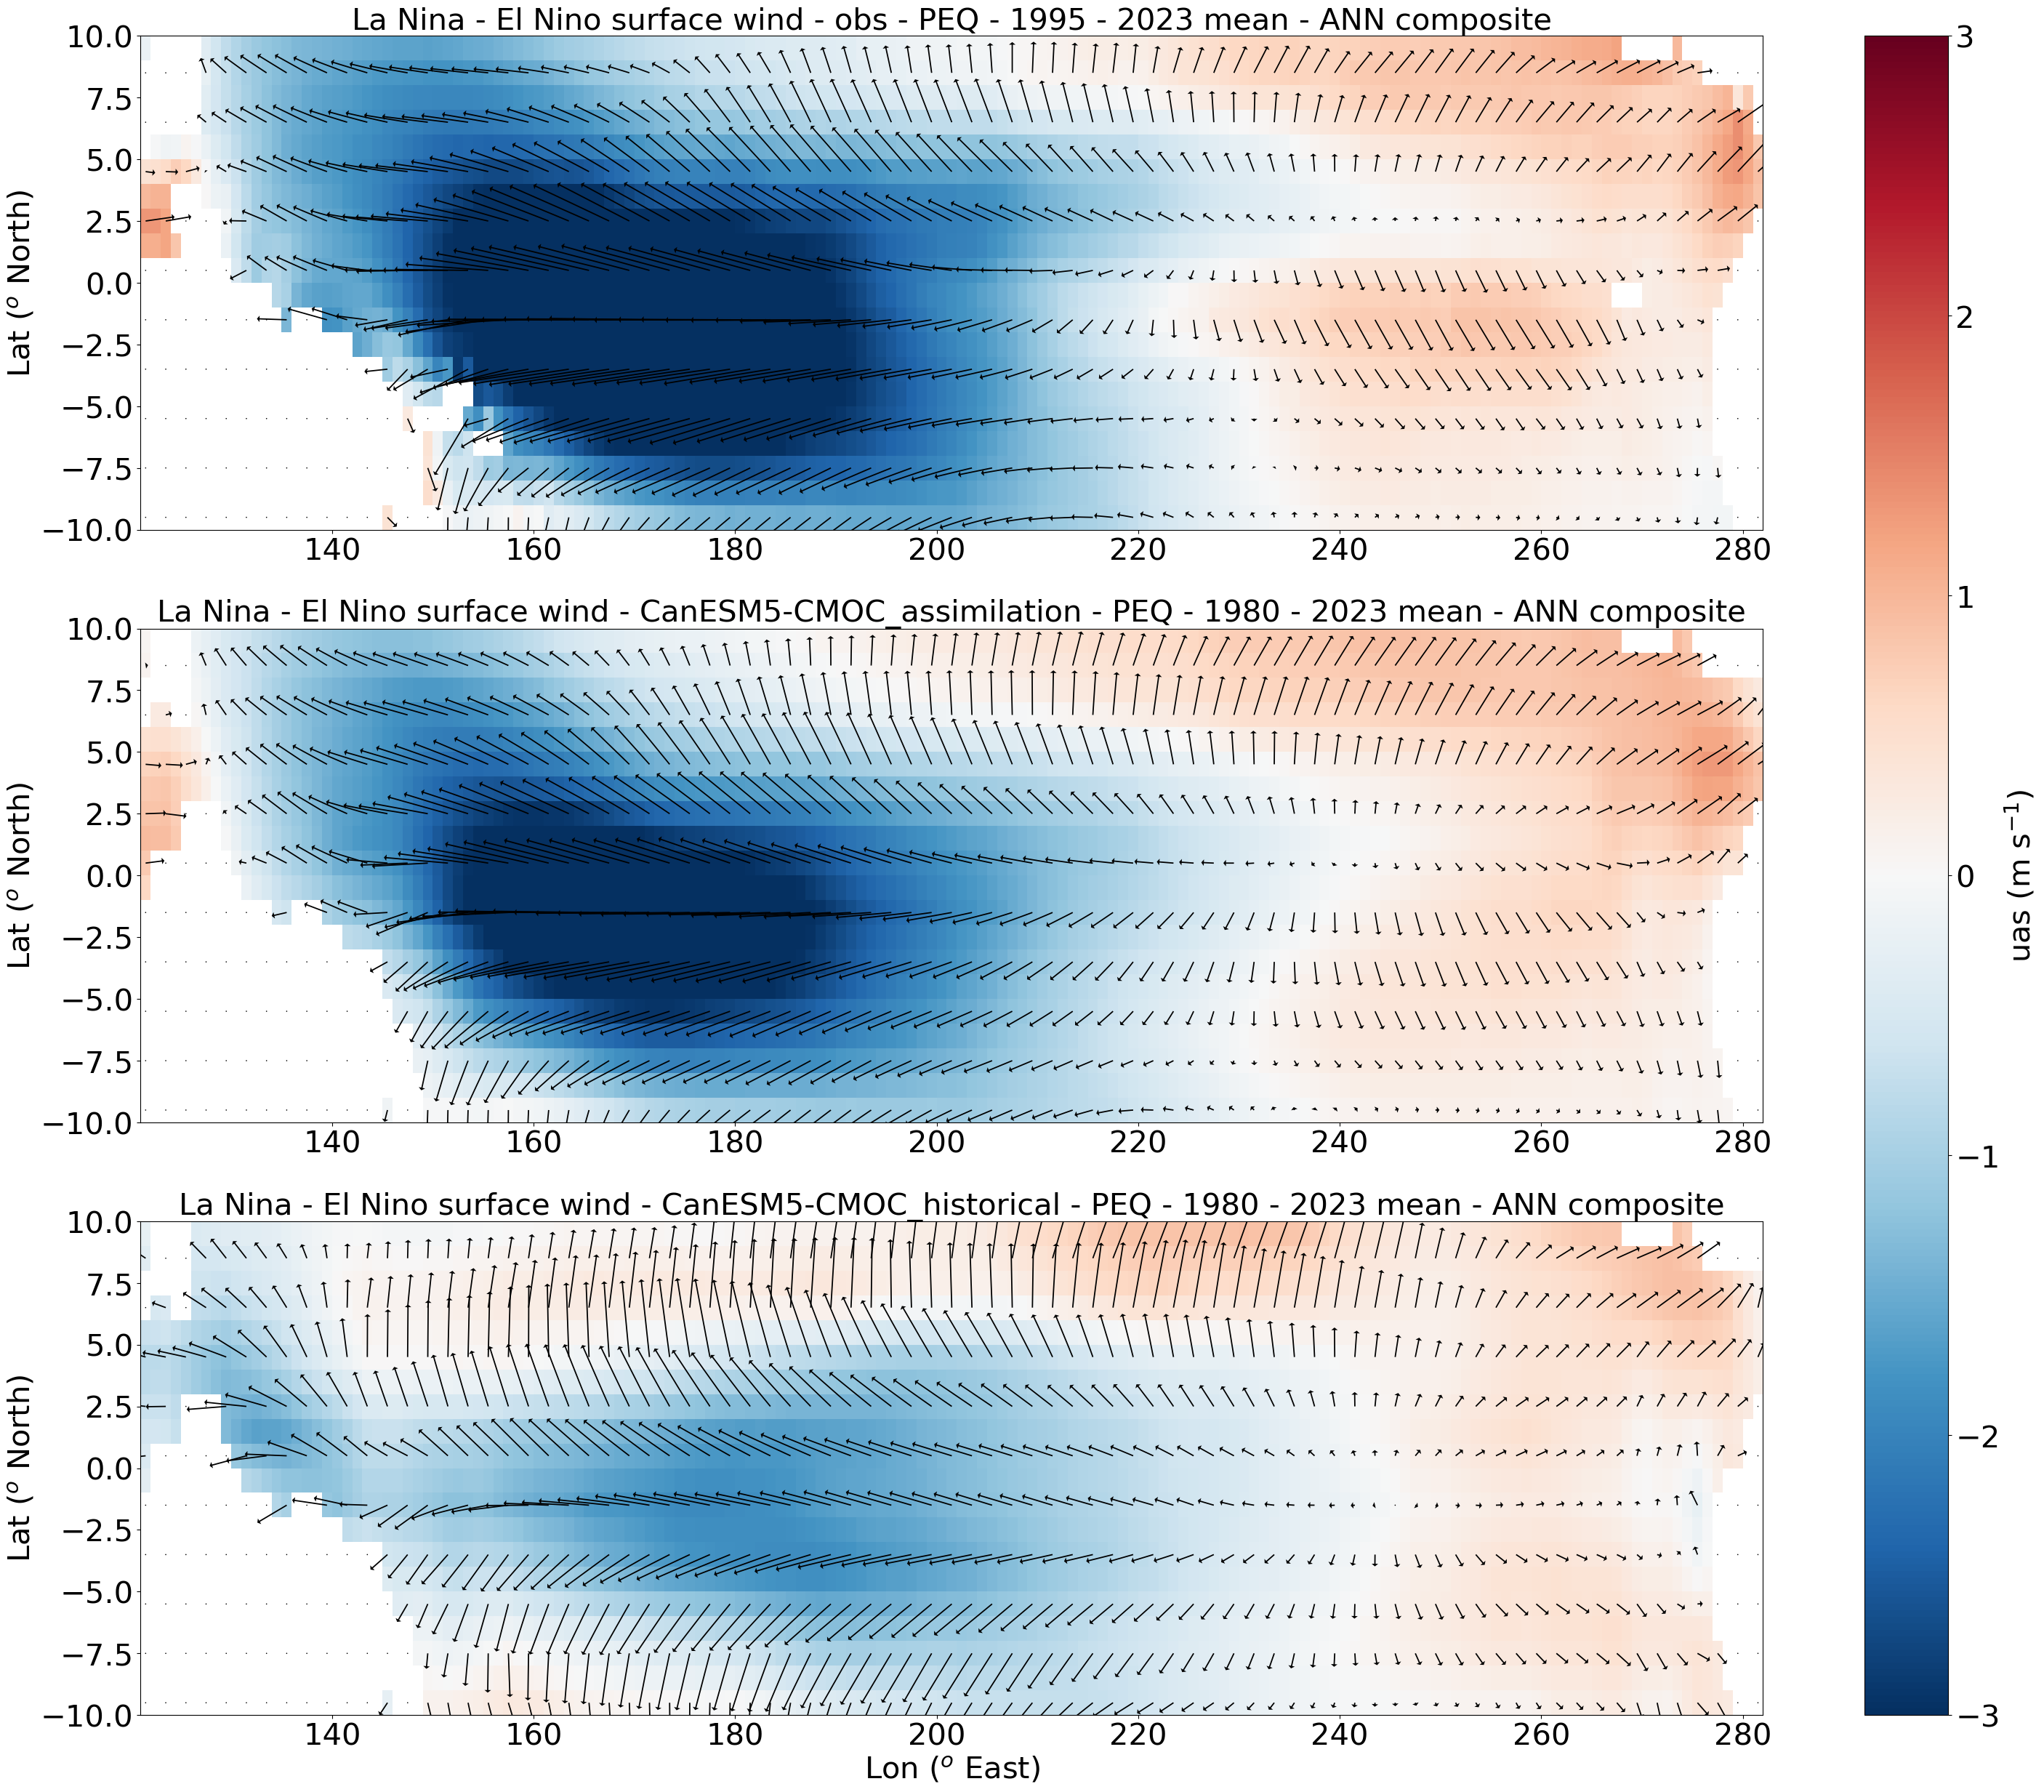

In [24]:
varx = 'uas'
vary = 'vas'
var_color = 'uas'

model_experiment = ['observation', 'CanESM5 assimilation', 'CanESM5 historical']
season_to_plot = 'ANN'
figsize = (36,30)


title = f'La Nina - El Nino surface wind'
bms_label =  'PEQ'

lev_range = 600
longitude = 260

ds_dicts_y = dict_em_diff[vary]
ds_dicts_x = dict_em_diff[varx]
ds_dicts_color = dict_em_diff[var_color]
colorbar_label = f'{var_color} ({units[var_color]})'

ds_list = experiment_finder(dict_em_data[var_color], model_experiment)


snapshot_aerial_quiver(
    ds_list=ds_list,
    quiver_dicts_X= ds_dicts_x,
    quiver_dicts_Y= ds_dicts_y,
    biome=bms_label,
    background_dict = ds_dicts_color,
    title=title,
    figsize=figsize,
    vmax= 3,
    vmin= -3,
    colorbar_label=colorbar_label,
    cmap = 'RdBu_r',
    lev_range=lev_range,
    scale_factor_X = 1,
    scale_factor_Y = 1,
    # arrow_scale = 350,
    quiver_step=2,
    headlength=2,
    headwidth=5,
    headaxislength=2,
    width = 0.0008,
    font_size=30
)